# 🧬 Exp 5 — BYOL + ResNet18 | Embryo Viability Classification

**Method:** Bootstrap Your Own Latent (BYOL) — Self-Supervised Learning  
**Backbone:** ResNet18 (ImageNet pretrained)  
**Phase 1:** Pretrain on 2344 images (labelled + unlabelled) — no labels used  
**Phase 2:** Fine-tune classifier on 754 labelled images  

### How BYOL differs from Barlow Twins
| | Barlow Twins (Exp 4) | BYOL (Exp 5) |
|---|---|---|
| Needs large batch | Yes (for cross-correlation) | **No** |
| Negative samples | No | No |
| Architecture | Single network | **Online + Target (EMA)** |
| Loss | Cross-correlation matrix | Prediction similarity |
| Small dataset fit | Good | **Better** |

---
### ✅ Before running
1. Runtime → Change runtime type → **T4 GPU**
2. Mount Drive in Cell 2
3. Run cells top to bottom

## 📦 Cell 1 — Install & Import

In [1]:
!pip install -q torchvision matplotlib scikit-learn seaborn tqdm grad-cam

import os, json, time, copy, random, shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, f1_score
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 82.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 🔗 Cell 2 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


## ⚙️ Cell 3 — Configuration

In [16]:
# ── Paths ─────────────────────────────────────────────────────────────────
LABELLED_DIR   = '/content/drive/MyDrive/embryo_dataset_looklike/labelled_embryos/fine_tuned_labeled'
UNLABELLED_DIR = '/content/drive/MyDrive/embryo_dataset_looklike/labelled_embryos/pretrained_unlabeled'
CHECKPOINT_DIR = '/content/drive/MyDrive/embryo_checkpoints/byol'
LOG_DIR        = '/content/drive/MyDrive/embryo_logs/byol'
SPLIT_DIR      = Path('/content/embryo_split_byol')

# ── Image sizes ────────────────────────────────────────────────────────────
SSL_IMG_SIZE = 96       # SSL pretraining (fast)
FT_RESIZE_TO = (400, 400)
FT_CROP_SIZE = 384       # fine-tuning

# ── Phase 1: BYOL pretraining ──────────────────────────────────────────────
SSL_EPOCHS       = 100
SSL_BATCH_SIZE   = 64    # was 128 — BYOL is heavier than Barlow (two networks)
SSL_LR           = 3e-4
SSL_WEIGHT_DECAY = 1e-4
EMA_DECAY        = 0.996
PROJ_HIDDEN      = 256
PROJ_OUT         = 128
PRED_HIDDEN      = 256
SSL_IMG_SIZE     = 128   # was 224 — halving resolution = 4x faster

# ── Phase 2: Fine-tuning ───────────────────────────────────────────────────
FT_EPOCHS      = 80
FT_BATCH_SIZE  = 16
LR_HEAD        = 1e-3
LR_FEATURE     = 1e-5
WEIGHT_DECAY   = 1e-3
PATIENCE       = 20
UNFREEZE_EPOCH = 10
WARMUP_EPOCHS  = 5      # use CrossEntropy before switching to Focal Loss

CLASS_NAMES = ['non_viable', 'viable']
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

print('Config ready.')
print(f'  SSL epochs     : {SSL_EPOCHS}')
print(f'  EMA decay (τ)  : {EMA_DECAY}')
print(f'  SSL batch size : {SSL_BATCH_SIZE}')
print(f'  FT  epochs     : {FT_EPOCHS}')

Config ready.
  SSL epochs     : 100
  EMA decay (τ)  : 0.996
  SSL batch size : 64
  FT  epochs     : 80


## 🗂️ Cell 4 — Dataset Inspection

In [17]:
labelled_path   = Path(LABELLED_DIR)
unlabelled_path = Path(UNLABELLED_DIR)

assert labelled_path.exists(),   f'Not found: {LABELLED_DIR}'
assert unlabelled_path.exists(), f'Not found: {UNLABELLED_DIR}'

viable_imgs     = list((labelled_path / 'viable').glob('*.*'))
nonviable_imgs  = list((labelled_path / 'non_viable').glob('*.*'))
unlabelled_imgs = list(unlabelled_path.glob('*.*'))

print(f'Labelled   viable     : {len(viable_imgs)}')
print(f'Labelled   non_viable : {len(nonviable_imgs)}')
print(f'Unlabelled            : {len(unlabelled_imgs)}')
print(f'Total SSL pretraining : {len(viable_imgs)+len(nonviable_imgs)+len(unlabelled_imgs)}')

Labelled   viable     : 234
Labelled   non_viable : 520
Unlabelled            : 1590
Total SSL pretraining : 2344


## 🔀 Cell 5 — Train / Val / Test Split

In [18]:
from sklearn.model_selection import train_test_split

if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)
    print('Old split removed.')

for split in ['train', 'val', 'test']:
    for cls in CLASS_NAMES:
        (SPLIT_DIR / split / cls).mkdir(parents=True, exist_ok=True)

def do_split(imgs, cls_name):
    tr, tmp = train_test_split(imgs, test_size=0.25, random_state=SEED)
    vl, te  = train_test_split(tmp,  test_size=0.40, random_state=SEED)
    for subset, files in [('train', tr), ('val', vl), ('test', te)]:
        for f in files:
            shutil.copy(f, SPLIT_DIR / subset / cls_name / Path(f).name)
    return len(tr), len(vl), len(te)

for cls, imgs in [('viable', viable_imgs), ('non_viable', nonviable_imgs)]:
    tr, vl, te = do_split(imgs, cls)
    print(f'  {cls:12s}  train={tr}  val={vl}  test={te}')

for sp in ['train', 'val', 'test']:
    counts = {c: len(list((SPLIT_DIR/sp/c).glob('*'))) for c in CLASS_NAMES}
    print(f'{sp:6s}: {counts}')

Old split removed.
  viable        train=175  val=35  test=24
  non_viable    train=390  val=78  test=52
train : {'non_viable': 390, 'viable': 175}
val   : {'non_viable': 78, 'viable': 35}
test  : {'non_viable': 52, 'viable': 24}


## 🔄 Cell 6 — BYOL Dataset & Augmentations

In [19]:
class BYOLDataset(Dataset):
    """
    Returns two differently-augmented views of each image.
    Used for BYOL SSL pretraining — no labels needed.
    """
    VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}

    def __init__(self, image_paths, transform):
        self.paths     = [p for p in image_paths
                          if Path(p).suffix.lower() in self.VALID_EXTS]
        self.transform = transform
        print(f'BYOL dataset: {len(self.paths)} valid images')

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert('RGB')
        except Exception:
            img = Image.new('RGB', (SSL_IMG_SIZE, SSL_IMG_SIZE))
        # Two independent augmentations of the same image
        return self.transform(img), self.transform(img)


# BYOL uses two asymmetric augmentation pipelines
# View 1: stronger augmentation (online network sees this)
# View 2: weaker augmentation  (target network sees this)
# Here we use same pipeline — simpler, works well for small datasets
byol_transform = transforms.Compose([
    transforms.Resize((SSL_IMG_SIZE, SSL_IMG_SIZE)),  # now 128x128
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.4, contrast=0.4,
                           saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.2),
    #transforms.GaussianBlur(kernel_size=7, sigma=(0.1, 2.0)),  # kernel must be odd and smaller
    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),  # was 7, must be odd
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

all_pretrain_paths = viable_imgs + nonviable_imgs + unlabelled_imgs
random.shuffle(all_pretrain_paths)

byol_dataset = BYOLDataset(all_pretrain_paths, byol_transform)
byol_loader  = DataLoader(
    byol_dataset,
    batch_size=SSL_BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
    persistent_workers=True,
)
print(f'Batches/epoch : {len(byol_loader)}')
print(f'Est. time/epoch : ~{len(byol_loader)*0.4:.0f}s on T4')
print(f'Est. total SSL  : ~{len(byol_loader)*0.4*SSL_EPOCHS/60:.0f} min')

BYOL dataset: 2344 valid images
Batches/epoch : 36
Est. time/epoch : ~14s on T4
Est. total SSL  : ~24 min


## 🏗️ Cell 7 — BYOL Model Architecture

BYOL uses two networks:
- **Online network:** encoder + projector + **predictor** (gets gradient updates)
- **Target network:** encoder + projector only (updated via EMA of online — no gradients)

The predictor is the key difference from Barlow Twins — it prevents collapse
without needing negative pairs or large batches.

In [20]:
class MLP(nn.Module):
    """Shared MLP used for both projector and predictor."""
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim,     hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
        )
    def forward(self, x): return self.net(x)


class BYOLEncoder(nn.Module):
    """ResNet18 backbone with fc removed + projector MLP."""
    def __init__(self, proj_hidden, proj_out):
        super().__init__()
        backbone     = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.encoder = nn.Sequential(*list(backbone.children())[:-1])  # 512-d out
        self.projector = MLP(512, proj_hidden, proj_out)

    def forward(self, x):
        feat = self.encoder(x).flatten(1)   # (B, 512)
        return self.projector(feat)          # (B, proj_out)


class BYOL(nn.Module):
    """
    Bootstrap Your Own Latent (BYOL)

    Online network: encoder + projector + predictor  (trained with gradients)
    Target network: encoder + projector              (EMA of online, no gradients)

    Loss: negative cosine similarity between
          online prediction and target projection (both directions)
    """
    def __init__(self, proj_hidden=256, proj_out=128,
                 pred_hidden=256, ema_decay=0.996):
        super().__init__()
        self.ema_decay = ema_decay

        # Online network
        self.online_encoder  = BYOLEncoder(proj_hidden, proj_out)
        self.online_predictor = MLP(proj_out, pred_hidden, proj_out)

        # Target network — initialised as copy of online, never gets gradients
        self.target_encoder  = BYOLEncoder(proj_hidden, proj_out)
        self._copy_online_to_target()
        for p in self.target_encoder.parameters():
            p.requires_grad = False

    def _copy_online_to_target(self):
        """Hard copy online weights to target at initialisation."""
        for op, tp in zip(self.online_encoder.parameters(),
                          self.target_encoder.parameters()):
            tp.data.copy_(op.data)

    @torch.no_grad()
    def update_target(self):
        """EMA update: target = τ * target + (1-τ) * online"""
        for op, tp in zip(self.online_encoder.parameters(),
                          self.target_encoder.parameters()):
            tp.data = self.ema_decay * tp.data + (1 - self.ema_decay) * op.data

    @staticmethod
    def _loss(pred, target):
        """Negative cosine similarity — symmetric, normalised."""
        pred   = F.normalize(pred,   dim=-1)
        target = F.normalize(target, dim=-1)
        return -(pred * target).sum(dim=-1).mean()

    def forward(self, view1, view2):
        # Online forward
        online_proj1 = self.online_encoder(view1)
        online_proj2 = self.online_encoder(view2)
        pred1 = self.online_predictor(online_proj1)
        pred2 = self.online_predictor(online_proj2)

        # Target forward (no gradients)
        with torch.no_grad():
            target_proj1 = self.target_encoder(view1)
            target_proj2 = self.target_encoder(view2)

        # Symmetric loss: online(v1) predicts target(v2) AND online(v2) predicts target(v1)
        loss = self._loss(pred1, target_proj2) + self._loss(pred2, target_proj1)
        return loss


byol_model = BYOL(
    proj_hidden=PROJ_HIDDEN,
    proj_out=PROJ_OUT,
    pred_hidden=PRED_HIDDEN,
    ema_decay=EMA_DECAY,
).to(DEVICE)

# Sanity check
with torch.no_grad():
    d1 = torch.randn(4, 3, SSL_IMG_SIZE, SSL_IMG_SIZE).to(DEVICE)
    d2 = torch.randn(4, 3, SSL_IMG_SIZE, SSL_IMG_SIZE).to(DEVICE)
    loss = byol_model(d1, d2)
print(f'Forward pass OK')
print(f'  Loss = {loss.item():.4f}  (should be close to -1.0 initially)')
total = sum(p.numel() for p in byol_model.parameters())
print(f'  Total params: {total:,}')

Forward pass OK
  Loss = 0.0566  (should be close to -1.0 initially)
  Total params: 22,748,160


## 🚀 Cell 8 — Phase 1: BYOL Pretraining

In [21]:
# Only online network parameters get gradients
ssl_optimizer = optim.AdamW(
    list(byol_model.online_encoder.parameters()) +
    list(byol_model.online_predictor.parameters()),
    lr=SSL_LR,
    weight_decay=SSL_WEIGHT_DECAY
)
ssl_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    ssl_optimizer, T_max=SSL_EPOCHS, eta_min=1e-6
)

ssl_history  = {'loss': []}
best_ssl_loss = float('inf')
SSL_CKPT = os.path.join(CHECKPOINT_DIR, 'byol_pretrained.pth')

print(f'Phase 1: BYOL SSL Pretraining — {SSL_EPOCHS} epochs')
print(f'Images  : {len(byol_dataset)}  |  '
      f'Batch: {SSL_BATCH_SIZE}  |  '
      f'Batches/epoch: {len(byol_loader)}')
print('=' * 65)

for epoch in range(SSL_EPOCHS):
    byol_model.train()
    epoch_loss = 0.0
    t0 = time.time()

    pbar = tqdm(byol_loader,
                desc=f'Epoch {epoch+1:03d}/{SSL_EPOCHS}',
                leave=False, ncols=80)

    for view1, view2 in pbar:
        view1, view2 = view1.to(DEVICE), view2.to(DEVICE)
        ssl_optimizer.zero_grad()
        loss = byol_model(view1, view2)
        loss.backward()
        ssl_optimizer.step()

        # EMA update target network after every batch
        byol_model.update_target()

        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    epoch_loss /= len(byol_loader)
    ssl_scheduler.step()
    ssl_history['loss'].append(epoch_loss)

    if epoch_loss < best_ssl_loss:
        best_ssl_loss = epoch_loss
        torch.save(byol_model.state_dict(), SSL_CKPT)

    print(f'Epoch [{epoch+1:03d}/{SSL_EPOCHS}]  '
          f'Loss={epoch_loss:.4f}  '
          f'| {time.time()-t0:.0f}s')

print(f'Pretraining done. Best loss: {best_ssl_loss:.4f}')
print(f'Backbone saved -> {SSL_CKPT}')

Phase 1: BYOL SSL Pretraining — 100 epochs
Images  : 2344  |  Batch: 64  |  Batches/epoch: 36


Epoch 001/100:   0%|                                     | 0/36 [00:00<?, ?it/s]

Epoch [001/100]  Loss=-0.7716  | 47s


Epoch 002/100:   0%|                                     | 0/36 [00:00<?, ?it/s]

Epoch [002/100]  Loss=-1.0971  | 50s


...

Epoch [079/100]  Loss=-1.9765  | 48s


Epoch 080/100:   0%|                                     | 0/36 [00:00<?, ?it/s]

Epoch [080/100]  Loss=-1.9763  | 49s


Epoch 081/100:   0%|                                     | 0/36 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 📈 Cell 9 — SSL Pretraining Curve

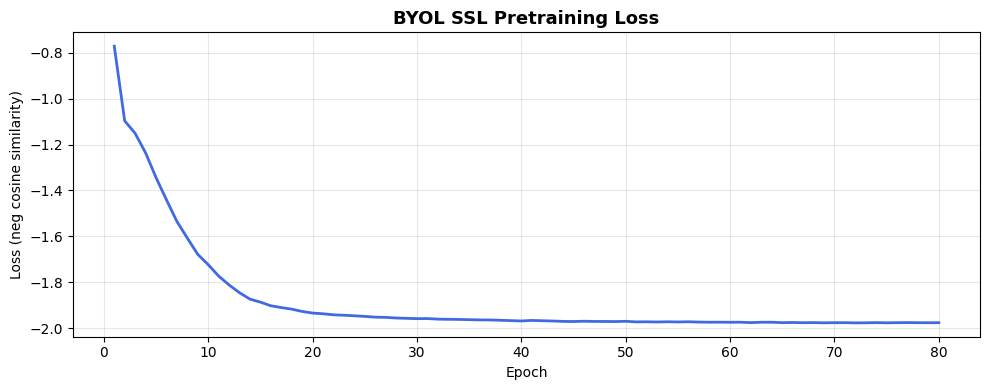

Expected: loss decreases from ~-1.0 toward -2.0 as representations improve


In [22]:
fig, ax = plt.subplots(figsize=(10, 4))
ep = range(1, len(ssl_history['loss'])+1)
ax.plot(ep, ssl_history['loss'], color='royalblue', lw=2)
ax.set_title('BYOL SSL Pretraining Loss', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (neg cosine similarity)')
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(LOG_DIR, 'byol_ssl_curve.png'), dpi=150)
plt.show()
print('Expected: loss decreases from ~-1.0 toward -2.0 as representations improve')

## 🏗️ Cell 10 — Build Classifier on Pretrained BYOL Backbone

In [23]:
class EmbryoClassifier(nn.Module):
    """
    BYOL pretrained ResNet18 encoder + classification head.
    Uses the ONLINE encoder (target encoder also works — online is slightly better).
    """
    def __init__(self, encoder, num_classes=2, freeze=True):
        super().__init__()
        self.encoder = encoder  # ResNet18 body (512-d output)
        if freeze:
            for p in self.encoder.parameters():
                p.requires_grad = False
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.encoder(x).flatten(1))


# Load best BYOL checkpoint and extract online encoder
byol_model.load_state_dict(
    torch.load(SSL_CKPT, map_location=DEVICE)
)
# Use the online encoder's backbone (without projector)
pretrained_backbone = byol_model.online_encoder.encoder

ft_model = EmbryoClassifier(
    encoder=pretrained_backbone,
    num_classes=2,
    freeze=True
).to(DEVICE)

# Sanity check at fine-tune resolution
with torch.no_grad():
    dummy = torch.randn(2, 3, FT_CROP_SIZE, FT_CROP_SIZE).to(DEVICE)
    out   = ft_model(dummy)
print(f'Classifier OK — output shape: {out.shape}')
trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in ft_model.parameters())
print(f'Trainable: {trainable:,} / {total:,} (head only, backbone frozen)')

Classifier OK — output shape: torch.Size([2, 2])
Trainable: 148,418 / 11,324,930 (head only, backbone frozen)


## 🔄 Cell 11 — Fine-tuning DataLoaders

In [24]:
train_transform = transforms.Compose([
    transforms.Resize(FT_RESIZE_TO),
    transforms.RandomCrop(FT_CROP_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
val_test_transform = transforms.Compose([
    transforms.Resize(FT_RESIZE_TO),
    transforms.CenterCrop(FT_CROP_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = datasets.ImageFolder(SPLIT_DIR/'train', transform=train_transform)
val_ds   = datasets.ImageFolder(SPLIT_DIR/'val',   transform=val_test_transform)
test_ds  = datasets.ImageFolder(SPLIT_DIR/'test',  transform=val_test_transform)
print(f'Class -> index: {train_ds.class_to_idx}')

# Weighted sampler to handle 2.2:1 class imbalance
targets      = [s[1] for s in train_ds.samples]
class_counts = np.bincount(targets)
sample_wts   = [1.0/class_counts[t] for t in targets]
sampler = WeightedRandomSampler(
    sample_wts,
    num_samples=int(class_counts.max())*len(CLASS_NAMES),
    replacement=True
)
train_loader = DataLoader(train_ds, batch_size=FT_BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=FT_BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=FT_BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f'Batches -> train:{len(train_loader)}  val:{len(val_loader)}  test:{len(test_loader)}')

Class -> index: {'non_viable': 0, 'viable': 1}
Batches -> train:49  val:8  test:5


## 🎯 Cell 12 — Loss Functions & Optimiser

In [25]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.65, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce      = F.cross_entropy(inputs, targets, reduction='none')
        pt      = torch.exp(-ce)
        alpha_t = torch.where(targets==1,
                              torch.tensor(self.alpha,     device=inputs.device),
                              torch.tensor(1-self.alpha,   device=inputs.device))
        return (alpha_t * (1-pt)**self.gamma * ce).mean()

ce_criterion    = nn.CrossEntropyLoss()         # warmup epochs
focal_criterion = FocalLoss(alpha=0.65, gamma=1.5)  # main training
print('CrossEntropy (warmup) + Focal Loss (main) ready.')

def make_optimizer(model, unfreeze_backbone=False):
    head_ids  = {id(p) for p in model.classifier.parameters()}
    bb_params = [p for p in model.parameters() if id(p) not in head_ids]
    groups = [{'params': list(model.classifier.parameters()), 'lr': LR_HEAD}]
    if unfreeze_backbone:
        groups.insert(0, {'params': bb_params, 'lr': LR_FEATURE})
    return optim.AdamW(groups, weight_decay=WEIGHT_DECAY)

ft_optimizer = make_optimizer(ft_model, unfreeze_backbone=False)
ft_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    ft_optimizer, T_max=FT_EPOCHS, eta_min=1e-6
)
print('Optimiser ready.')

CrossEntropy (warmup) + Focal Loss (main) ready.
Optimiser ready.


## 🚀 Cell 13 — Phase 2: Fine-tuning Loop

In [26]:
def run_epoch(model, loader, criterion, optimizer=None, phase='train'):
    is_train = phase == 'train'
    model.train() if is_train else model.eval()
    running_loss = correct = total = 0
    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if is_train: optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            if is_train: loss.backward(); optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1)==labels).sum().item()
            total   += imgs.size(0)
    return running_loss/total, correct/total

def get_f1(model, loader):
    model.eval()
    p, l = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            p.extend(model(imgs.to(DEVICE)).argmax(1).cpu().numpy())
            l.extend(labels.numpy())
    return f1_score(l, p, average='macro')


ft_history = {'train_loss':[],'train_acc':[],'val_loss':[],'val_acc':[],'val_f1':[]}
best_val_f1  = 0.0
best_wts     = copy.deepcopy(ft_model.state_dict())
patience_ctr = 0
bb_unfrozen  = False
FT_CKPT      = os.path.join(CHECKPOINT_DIR, 'byol_best_finetuned.pth')

print(f'Phase 2: Fine-tuning {FT_EPOCHS} epochs')
print(f'  Warmup   : CrossEntropy for first {WARMUP_EPOCHS} epochs')
print(f'  Main     : Focal Loss from epoch {WARMUP_EPOCHS+1}')
print(f'  Unfreeze : Backbone at epoch {UNFREEZE_EPOCH}')
print('=' * 75)

for epoch in range(FT_EPOCHS):
    t0 = time.time()

    # Select loss: CrossEntropy warmup -> Focal Loss
    criterion = ce_criterion if epoch < WARMUP_EPOCHS else focal_criterion

    # Progressive backbone unfreeze
    if not bb_unfrozen and epoch >= UNFREEZE_EPOCH:
        print(f'Epoch {epoch+1}: Unfreezing backbone...')
        for p in ft_model.parameters(): p.requires_grad = True
        ft_optimizer = make_optimizer(ft_model, unfreeze_backbone=True)
        ft_scheduler = optim.lr_scheduler.CosineAnnealingLR(
            ft_optimizer, T_max=FT_EPOCHS-epoch, eta_min=1e-6)
        bb_unfrozen = True

    tr_loss, tr_acc = run_epoch(ft_model, train_loader, criterion, ft_optimizer, 'train')
    vl_loss, vl_acc = run_epoch(ft_model, val_loader,   criterion, None, 'val')
    vl_f1           = get_f1(ft_model, val_loader)
    ft_scheduler.step()

    ft_history['train_loss'].append(tr_loss)
    ft_history['train_acc'].append(tr_acc)
    ft_history['val_loss'].append(vl_loss)
    ft_history['val_acc'].append(vl_acc)
    ft_history['val_f1'].append(vl_f1)

    loss_tag = 'CE' if epoch < WARMUP_EPOCHS else 'FL'
    print(f'[{loss_tag}] Epoch [{epoch+1:03d}/{FT_EPOCHS}] '
          f'Train loss={tr_loss:.4f} acc={tr_acc:.4f} | '
          f'Val loss={vl_loss:.4f} acc={vl_acc:.4f} f1={vl_f1:.4f} | '
          f'{time.time()-t0:.1f}s')

    if vl_f1 > best_val_f1:
        best_val_f1  = vl_f1
        patience_ctr = 0
        best_wts     = copy.deepcopy(ft_model.state_dict())
        torch.save({
            'model_state_dict': ft_model.state_dict(),
            'best_val_f1':      best_val_f1,
            'history':          ft_history,
            'class_to_idx':     train_ds.class_to_idx,
            'crop_size':        FT_CROP_SIZE,
        }, FT_CKPT)
        print(f'  -> Best saved (val_f1={best_val_f1:.4f})')
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

ft_model.load_state_dict(best_wts)
print(f'Fine-tuning complete. Best Val F1: {best_val_f1:.4f}')

Phase 2: Fine-tuning 80 epochs
  Warmup   : CrossEntropy for first 5 epochs
  Main     : Focal Loss from epoch 6
  Unfreeze : Backbone at epoch 10
[CE] Epoch [001/80] Train loss=0.7126 acc=0.5115 | Val loss=0.7051 acc=0.4779 f1=0.4113 | 15.3s
  -> Best saved (val_f1=0.4113)
[CE] Epoch [002/80] Train loss=0.6889 acc=0.5705 | Val loss=0.7064 acc=0.4336 f1=0.4134 | 16.5s
  -> Best saved (val_f1=0.4134)
[CE] Epoch [003/80] Train loss=0.7075 acc=0.5308 | Val loss=0.6826 acc=0.5929 f1=0.4781 | 15.1s
  -> Best saved (val_f1=0.4781)
[CE] Epoch [004/80] Train loss=0.6977 acc=0.5436 | Val loss=0.6980 acc=0.4690 f1=0.4053 | 15.2s
[CE] Epoch [005/80] Train loss=0.6872 acc=0.5679 | Val loss=0.7071 acc=0.4602 f1=0.3992 | 14.5s
[FL] Epoch [006/80] Train loss=0.1163 acc=0.5744 | Val loss=0.1244 acc=0.3274 f1=0.2867 | 14.7s
[FL] Epoch [007/80] Train loss=0.1172 acc=0.5346 | Val loss=0.1204 acc=0.3274 f1=0.2800 | 14.6s
[FL] Epoch [008/80] Train loss=0.1131 acc=0.5295 | Val loss=0.1227 acc=0.3097 f1=0.23

## 📈 Cell 14 — Fine-tuning Curves

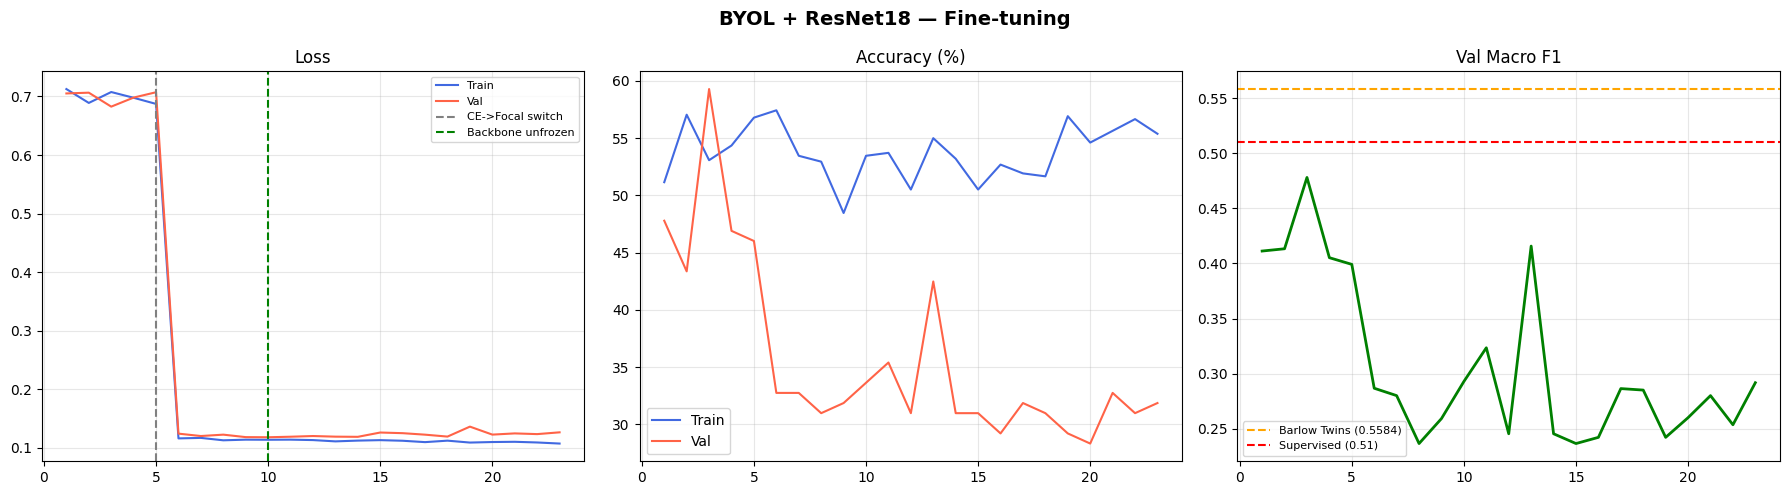

In [27]:
ep = range(1, len(ft_history['train_loss'])+1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('BYOL + ResNet18 — Fine-tuning', fontsize=14, fontweight='bold')

axes[0].plot(ep, ft_history['train_loss'], label='Train', color='royalblue')
axes[0].plot(ep, ft_history['val_loss'],   label='Val',   color='tomato')
axes[0].axvline(x=WARMUP_EPOCHS, color='gray', linestyle='--', label='CE->Focal switch')
axes[0].axvline(x=UNFREEZE_EPOCH, color='green', linestyle='--', label='Backbone unfrozen')
axes[0].set_title('Loss'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(ep, [a*100 for a in ft_history['train_acc']], label='Train', color='royalblue')
axes[1].plot(ep, [a*100 for a in ft_history['val_acc']],   label='Val',   color='tomato')
axes[1].set_title('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, ft_history['val_f1'], color='green', lw=2)
axes[2].axhline(y=0.5584, color='orange', linestyle='--', label='Barlow Twins (0.5584)')
axes[2].axhline(y=0.51,   color='red',    linestyle='--', label='Supervised (0.51)')
axes[2].set_title('Val Macro F1'); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(LOG_DIR, 'byol_ft_curves.png'), dpi=150)
plt.show()

## 🧪 Cell 15 — Test Set Evaluation

In [28]:
ft_model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs  = imgs.to(DEVICE)
        out   = ft_model(imgs)
        probs = torch.softmax(out, dim=1)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

test_acc = np.mean(np.array(all_preds)==np.array(all_labels))
test_f1  = f1_score(all_labels, all_preds, average='macro')
print(f'Test Accuracy : {test_acc*100:.2f}%')
print(f'Test Macro F1 : {test_f1:.4f}')
print()
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

Test Accuracy : 63.16%
Test Macro F1 : 0.5394

              precision    recall  f1-score   support

  non_viable       0.71      0.79      0.75        52
      viable       0.39      0.29      0.33        24

    accuracy                           0.63        76
   macro avg       0.55      0.54      0.54        76
weighted avg       0.61      0.63      0.62        76



## 🔢 Cell 16 — Confusion Matrix & ROC Curve

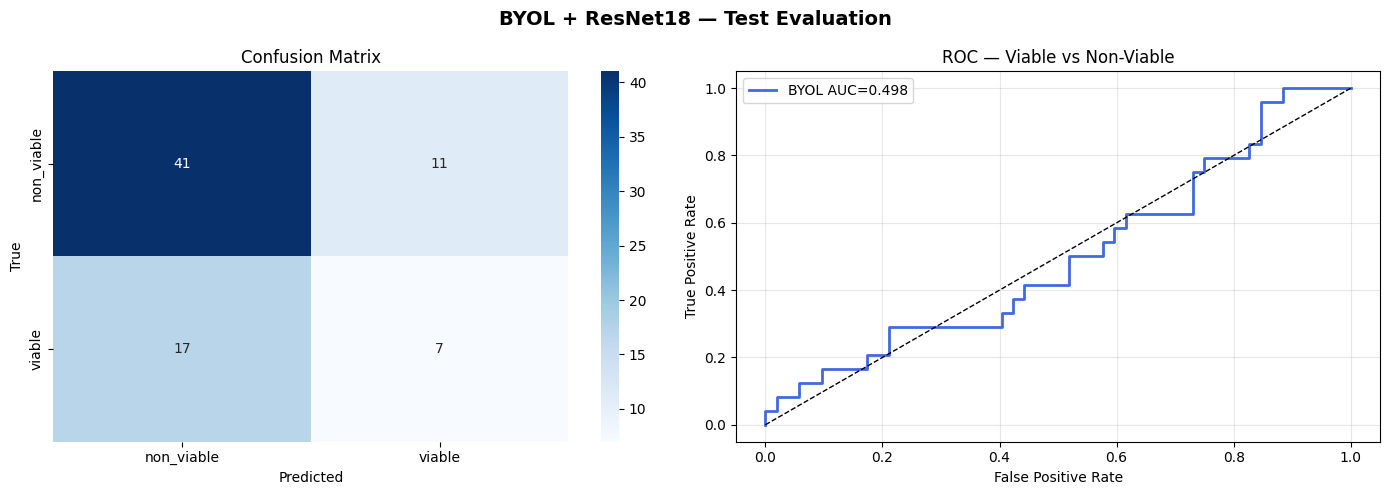

AUC: 0.4976


In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BYOL + ResNet18 — Test Evaluation', fontsize=14, fontweight='bold')

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax1)
ax1.set_title('Confusion Matrix')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')

viable_idx    = train_ds.class_to_idx['viable']
binary_labels = [1 if l==viable_idx else 0 for l in all_labels]
binary_probs  = [p if viable_idx==1 else 1-p for p in all_probs]
fpr, tpr, _   = roc_curve(binary_labels, binary_probs)
roc_auc       = auc(fpr, tpr)

ax2.plot(fpr, tpr, color='royalblue', lw=2, label=f'BYOL AUC={roc_auc:.3f}')
ax2.plot([0,1],[0,1],'k--',lw=1)
# Reference lines from previous experiments
ax2.axhline(y=0, color='gray', lw=0)  # placeholder
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC — Viable vs Non-Viable')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(LOG_DIR, 'byol_evaluation.png'), dpi=150)
plt.show()
print(f'AUC: {roc_auc:.4f}')

## 📊 Cell 17 — Updated Comparison Table

In [30]:
results = {
    'Exp1_ResNet18_Supervised': {
        'method': 'Supervised only',
        'test_f1': 0.51, 'test_acc': 60.53, 'auc': 0.5256,
        'viable_f1': 0.29, 'nonviable_f1': 0.73, 'unlabelled': False},
    'Exp4_BarlowTwins_ResNet18': {
        'method': 'SSL: Barlow Twins',
        'test_f1': 0.5584, 'test_acc': 59.21, 'auc': 0.5569,
        'viable_f1': 0.44, 'nonviable_f1': 0.68, 'unlabelled': True},
    'Exp5_BYOL_ResNet18': {
        'method': 'SSL: BYOL',
        'test_f1':  round(test_f1, 4),
        'test_acc': round(test_acc*100, 2),
        'auc':      round(roc_auc, 4),
        'viable_f1': None,   # fill from classification_report above
        'nonviable_f1': None,
        'unlabelled': True},
}

print(f'{'Experiment':<30} {'Method':<22} {'Test F1':>8} {'Test Acc':>10} {'AUC':>8} {'Unlabelled':>12}')
print('-' * 95)
for name, m in results.items():
    print(f"{name:<30} {m['method']:<22} "
          f"{m['test_f1']:>8.4f} {m['test_acc']:>9.2f}% "
          f"{m['auc']:>8.4f} {str(m['unlabelled']):>12}")

path = os.path.join(LOG_DIR, 'comparison_table.json')
with open(path, 'w') as f:
    json.dump(results, f, indent=2)
print(f'Saved: {path}')

Experiment                     Method                  Test F1   Test Acc      AUC   Unlabelled
-----------------------------------------------------------------------------------------------
Exp1_ResNet18_Supervised       Supervised only          0.5100     60.53%   0.5256        False
Exp4_BarlowTwins_ResNet18      SSL: Barlow Twins        0.5584     59.21%   0.5569         True
Exp5_BYOL_ResNet18             SSL: BYOL                0.5394     63.16%   0.4976         True
Saved: /content/drive/MyDrive/embryo_logs/byol/comparison_table.json


## 💾 Cell 18 — Save Final Model

In [31]:
FINAL_CKPT = os.path.join(CHECKPOINT_DIR, 'final_byol_resnet18.pth')
torch.save({
    'model_state_dict': ft_model.state_dict(),
    'class_to_idx':     train_ds.class_to_idx,
    'crop_size':        FT_CROP_SIZE,
    'best_val_f1':      best_val_f1,
    'test_f1':          test_f1,
    'test_acc':         test_acc,
    'roc_auc':          float(roc_auc),
    'ssl_history':      ssl_history,
    'ft_history':       ft_history,
}, FINAL_CKPT)
print(f'Model saved -> {FINAL_CKPT}')

# TorchScript export
ft_model.eval()
dummy    = torch.randn(1, 3, FT_CROP_SIZE, FT_CROP_SIZE).to(DEVICE)
scripted = torch.jit.trace(ft_model, dummy)
scripted.save(os.path.join(CHECKPOINT_DIR, 'byol_scripted.pt'))

print()
print('=' * 50)
print('  FINAL RESULTS — BYOL + ResNet18')
print('=' * 50)
print(f'  Best Val F1   : {best_val_f1:.4f}')
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print(f'  Test Macro F1 : {test_f1:.4f}')
print(f'  ROC AUC       : {roc_auc:.4f}')
print('=' * 50)

Model saved -> /content/drive/MyDrive/embryo_checkpoints/byol/final_byol_resnet18.pth

  FINAL RESULTS — BYOL + ResNet18
  Best Val F1   : 0.4781
  Test Accuracy : 63.16%
  Test Macro F1 : 0.5394
  ROC AUC       : 0.4976
